#Decion tree and random forest as regressor

#1  Import the libraries



In [2]:
# 1️⃣ imports
import pandas as pd                     # data handling
import numpy as np                      # numeric helpers
import matplotlib.pyplot as plt         # quick plots
import seaborn as sns                   # prettier plots
from sklearn.datasets import fetch_california_housing  # ready‑made real dataset
from sklearn.model_selection import train_test_split   # split helper
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)                 # regression metrics
from sklearn.tree import DecisionTreeRegressor         # our first model
from sklearn.ensemble import RandomForestRegressor     # our second model


Exception in thread Thread-3 (attachment_entry):
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/debugpy/server/api.py", line 237, in listen
    sock, _ = endpoints_listener.accept()
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/socket.py", line 294, in accept
    fd, addr = self._accept()
               ^^^^^^^^^^^^^^
TimeoutError: timed out

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/google/colab/_debugpy.py", line 52, in attachment_entry
    debugpy.listen(_dap_port)
  File "/usr/local/lib/python3.11/dist-packages/debugpy/public_api.py", line 31, in wrapper
    return wrapped(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^

#2  Load and inspect the data

In [3]:
# 2️⃣ fetch a real‑world regression dataset
cal = fetch_california_housing(as_frame=True)  # returns frame + meta
df  = cal.frame                                # full dataframe

# quick peek
print(df.head())
print("\nShape:", df.shape)
print("\nNull values:\n", df.isna().sum())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Shape: (20640, 9)

Null values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


#3  Train / validation split

In [4]:
# 3️⃣ split 80 % / 20 %  (random_state gives repeatability)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('MedHouseVal', axis=1),   # features
    df['MedHouseVal'],                # target (median house value)
    test_size=0.2,
    random_state=42
)


#4  (Optionally) quick feature‑target scatter

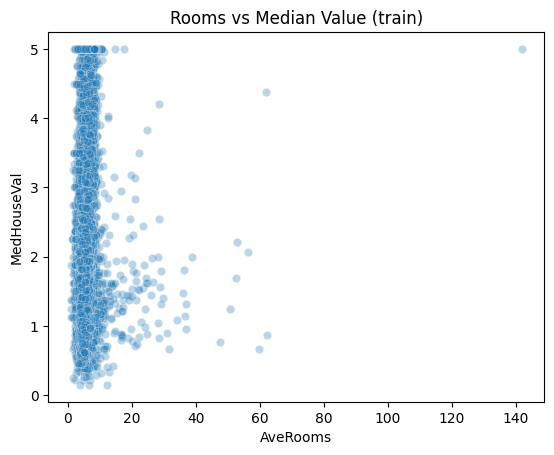

In [5]:
sns.scatterplot(x=X_train['AveRooms'], y=y_train, alpha=0.3)
plt.title("Rooms vs Median Value (train)")
plt.show()


#(Purely illustrative; skip in headless runs.)

#5  Train a Decision Tree Regressor

In [6]:
# 5️⃣ create & fit
dt = DecisionTreeRegressor(
        max_depth=None,        # let it grow fully; we can tune later
        random_state=42)
dt.fit(X_train, y_train)

# 5b️⃣ evaluate
pred_dt = dt.predict(X_test)
mae_dt  = mean_absolute_error(y_test, pred_dt)
mse_dt  = mean_squared_error(y_test, pred_dt)
r2_dt   = r2_score(y_test, pred_dt)

print(f"Decision Tree  MAE: {mae_dt:.3f}")
print(f"Decision Tree  MSE: {mse_dt:.3f}")
print(f"Decision Tree   R²: {r2_dt :.3f}")



Decision Tree  MAE: 0.455
Decision Tree  MSE: 0.495
Decision Tree   R²: 0.622


#6  Visualise (optional)


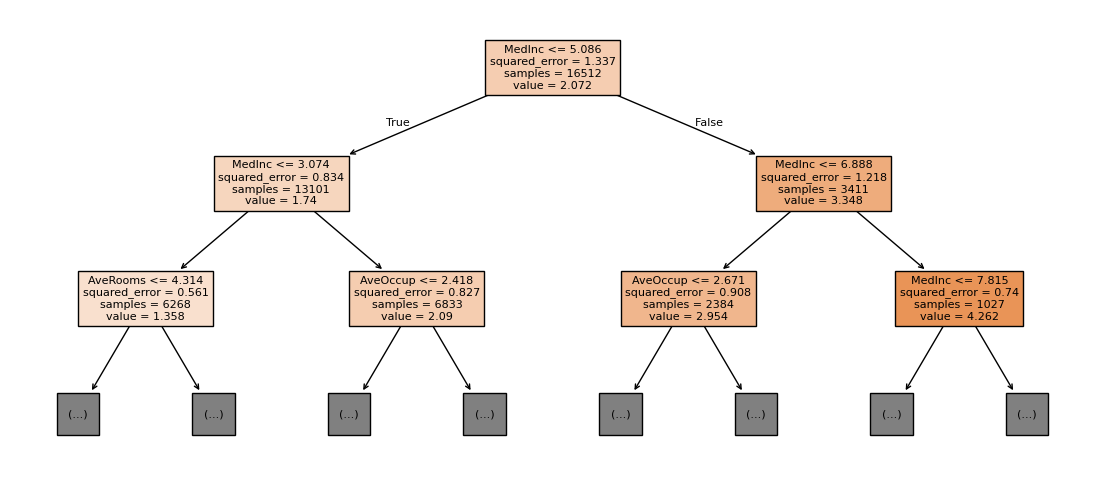

In [7]:
# 6️⃣ tiny example using plot_tree (for small depths)
from sklearn import tree
plt.figure(figsize=(14,6))
tree.plot_tree(dt,
               feature_names=cal.feature_names,
               filled=True,
               max_depth=2)   # show top 2 levels only
plt.show()


#7  Train a Random Forest Regressor

In [8]:
# 7️⃣ create & fit
rf = RandomForestRegressor(
        n_estimators=200,      # number of trees in the forest
        max_depth=None,
        n_jobs=-1,            # use all cores
        random_state=42)
rf.fit(X_train, y_train)

# 7b️⃣ evaluate
pred_rf = rf.predict(X_test)
mae_rf  = mean_absolute_error(y_test, pred_rf)
mse_rf  = mean_squared_error(y_test, pred_rf)
r2_rf   = r2_score(y_test, pred_rf)

print(f"Random Forest MAE: {mae_rf:.3f}")
print(f"Random Forest MSE: {mse_rf:.3f}")
print(f"Random Forest  R²: {r2_rf :.3f}")


Random Forest MAE: 0.327
Random Forest MSE: 0.254
Random Forest  R²: 0.806


#8  Compare the two models side‑by‑side

In [9]:
results = pd.DataFrame({
    'Model' : ['Decision Tree', 'Random Forest'],
    'MAE'   : [mae_dt, mae_rf],
    'MSE'   : [mse_dt, mse_rf],
    'R2'    : [r2_dt,  r2_rf]
})
print(results)


           Model       MAE       MSE        R2
0  Decision Tree  0.454679  0.495235  0.622076
1  Random Forest  0.326812  0.253976  0.806186


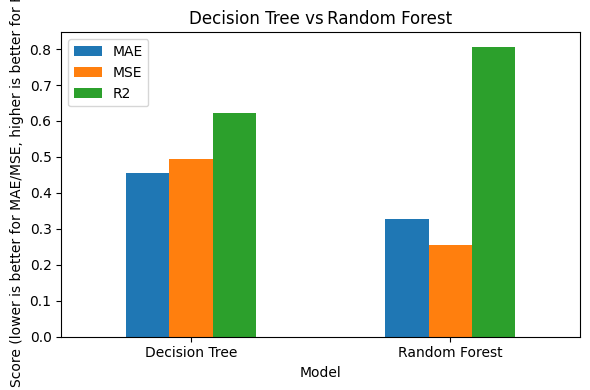

In [10]:
#A quick bar chart makes the gap obvious:

results.set_index('Model').plot(kind='bar', figsize=(6,4), rot=0)
plt.ylabel('Score (lower is better for MAE/MSE, higher is better for R²)')
plt.title('Decision Tree vs Random Forest')
plt.tight_layout()
plt.show()


#9  (Extra) basic hyper‑parameter tuning grid

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10]
}

grid_dt = GridSearchCV(
            DecisionTreeRegressor(random_state=42),
            param_grid,
            cv=5,
            scoring='neg_mean_absolute_error',
            n_jobs=-1)

grid_dt.fit(X_train, y_train)
print("Best Tree Params:", grid_dt.best_params_)
print("Best Validation MAE:", -grid_dt.best_score_)


Best Tree Params: {'max_depth': None, 'min_samples_leaf': 10}
Best Validation MAE: 0.40779425611041964


#10  Key Take‑aways

1.Decision Tree Regressor

>Easy to interpret, but unstable & prone to overfitting.

>Tunable via depth, min samples, etc.

2.Random Forest Regressor

>Ensemble of many trees → usually higher accuracy and better generalisation.

>Less interpretable; feature importance still available (rf.feature_importances_).

3.Workflow stays the same: load → split → fit → evaluate → tune.